# Линейный дискриминантный анализ (LDA)

В этом ноутбуке разберём **линейный дискриминантный анализ (LDA)** как метод понижения размерности и линейной классификации.

**Цели ноутбука:**
- Понять геометрическую и вероятностную интерпретацию LDA.
- Разобрать ключевые матрицы: *внутриклассовое* и *межклассовое* рассеяние.
- Реализовать LDA **с нуля на `numpy`**.
- Сравнить с готовой реализацией `LinearDiscriminantAnalysis` из `sklearn`.

---

**Содержание:** Идея LDA → Матрицы рассеяния → Реализация с нуля → Сравнение с sklearn.


## Идея LDA

Предположим, у нас есть несколько классов в $\mathbb{R}^d$. Мы хотим найти линейное отображение
$$W: \mathbb{R}^d \to \mathbb{R}^k,$$
такое, что в новом пространстве классы **хорошо разделимы**.

Идея:
- объекты одного класса должны располагаться **компактно** (малое внутриклассовое рассеяние),
- центры разных классов должны быть **как можно дальше** друг от друга (большое межклассовое рассеяние).

В простейшем двухклассовом случае ($K=2$) LDA ищет направление $w$, на которое мы проектируем точки,
чтобы отношение "межклассового расстояния" к "внутриклассовому разбросу" было максимальным. Это классический критерий **Фишера**.


## Формулы: матрицы рассеяния

Пусть есть классы $k = 1, \dots, K$. Обозначим:
- $\mu_k$ — вектор среднего по признакам внутри класса $k$,
- $\mu$ — общее среднее по всей выборке.

**Внутриклассовое рассеяние** (within-class scatter):
$$
S_W = \sum_{k=1}^K \sum_{x \in C_k} (x - \mu_k)(x - \mu_k)^T.
$$
Оно измеряет, насколько сильно объекты "размазаны" вокруг своих классовых средних.

**Межклассовое рассеяние** (between-class scatter):
$$
S_B = \sum_{k=1}^K n_k (\mu_k - \mu)(\mu_k - \mu)^T,
$$
где $n_k$ — число объектов в классе $k$. Оно измеряет, насколько далеко друг от друга расположены центры классов.

Классический критерий для поиска матрицы проекции $W$:
$$
J(W) = \frac{\det(W^T S_B W)}{\det(W^T S_W W)}.
$$
Оптимальные столбцы $W$ оказываются **собственными векторами** матрицы
$$
S_W^{-1} S_B.
$$
Мы берём несколько собственных векторов с наибольшими собственными значениями и получаем линейное отображение в пространство меньшей размерности.


## Генерация синтетических данных

Создадим 3 класса в двумерном пространстве и попробуем:
- обучить LDA с нуля для проекции в 1D,
- визуально посмотреть, как классы разделяются по этой проекции,
- затем сравнить с `sklearn`.


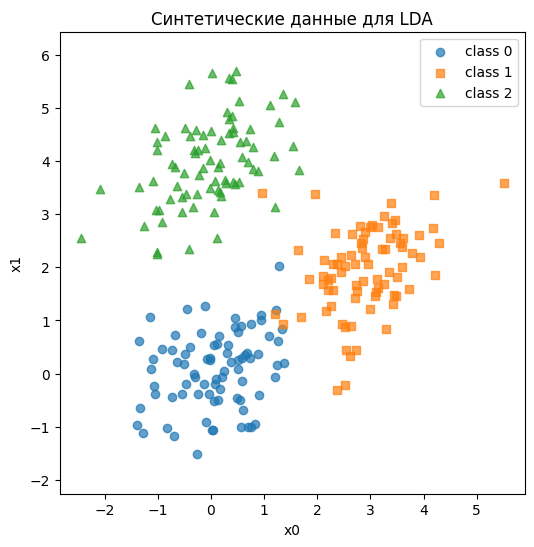

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_per_class = 80

mean1 = [0, 0]
mean2 = [3, 2]
mean3 = [0, 4]
cov = [[0.6, 0.2], [0.2, 0.6]]

X1 = np.random.multivariate_normal(mean1, cov, size=n_per_class)
X2 = np.random.multivariate_normal(mean2, cov, size=n_per_class)
X3 = np.random.multivariate_normal(mean3, cov, size=n_per_class)

X = np.vstack([X1, X2, X3])
y = np.array([0] * n_per_class + [1] * n_per_class + [2] * n_per_class)

plt.figure(figsize=(6, 6))
for cls, marker, color in zip([0, 1, 2], ["o", "s", "^"], ["tab:blue", "tab:orange", "tab:green"]):
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, color=color, label=f"class {cls}", alpha=0.7)
plt.legend()
plt.title("Синтетические данные для LDA")
plt.xlabel("x0")
plt.ylabel("x1")
plt.axis("equal")
plt.show()


## Реализация LDA с нуля

Сделаем простую реализацию LDA для многоклассового случая:
- на шаге `fit` посчитаем $S_W$ и $S_B$,
- решим обобщённую задачу на собственные значения для $S_W^{-1} S_B$,
- выберем `n_components` собственных векторов с наибольшими собственными значениями и сформируем матрицу проекции `W`,
- на шаге `transform` будем умножать `X` на `W`,
- для простоты классификации будем использовать **ближайший средний** (nearest class mean) в проекции.


In [2]:
class LDAScratch:
    def __init__(self, n_components: int = 1):
        self.n_components = n_components
        self.W_ = None  # матрица проекции (d x n_components)
        self.class_means_ = None  # средние классов в проекции
        self.classes_ = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)

        # Общее среднее
        mu = X.mean(axis=0)

        # Матрицы рассеяния
        S_W = np.zeros((n_features, n_features))
        S_B = np.zeros((n_features, n_features))

        for cls in self.classes_:
            X_k = X[y == cls]
            mu_k = X_k.mean(axis=0)
            # Внутриклассовое рассеяние класса cls
            X_centered = X_k - mu_k
            S_W += X_centered.T @ X_centered
            # Межклассовое рассеяние
            n_k = X_k.shape[0]
            diff = (mu_k - mu).reshape(-1, 1)
            S_B += n_k * (diff @ diff.T)

        # Решаем задачу на собственные значения для S_W^{-1} S_B
        # Добавим небольшую регуляризацию на диагональ S_W для устойчивости
        reg = 1e-6 * np.eye(n_features)
        S_W_reg = S_W + reg

        # В общем случае лучше решать обобщённую задачу, но для простоты:
        A = np.linalg.inv(S_W_reg) @ S_B
        eigvals, eigvecs = np.linalg.eig(A)

        # Сортируем собственные векторы по убыванию собственного значения
        idx = np.argsort(eigvals.real)[::-1]
        eigvecs = eigvecs[:, idx]

        n_components = min(self.n_components, n_features, len(self.classes_) - 1)
        self.W_ = eigvecs[:, :n_components].real

        # Посчитаем средние классов в проекции (для классификации по ближайшему среднему)
        Z = self.transform(X)
        self.class_means_ = np.array([
            Z[y == cls].mean(axis=0) for cls in self.classes_
        ])

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.W_ is None:
            raise ValueError("Model is not fitted yet")
        return np.asarray(X) @ self.W_

    def predict(self, X: np.ndarray) -> np.ndarray:
        Z = self.transform(X)
        # расстояние до средних классов в проекции
        dists = ((Z[:, None, :] - self.class_means_[None, :, :]) ** 2).sum(axis=2)
        idx_min = np.argmin(dists, axis=1)
        return self.classes_[idx_min]


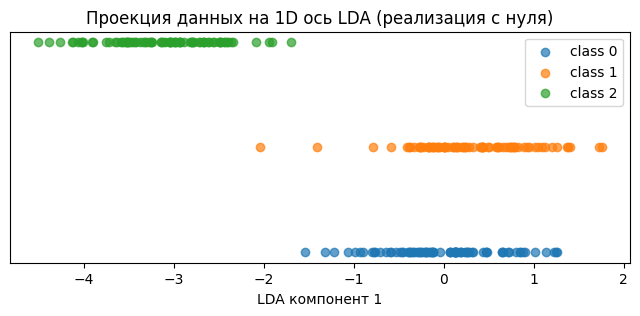

Точность классификации (LDA с нуля): 0.729


In [3]:
lda_scratch = LDAScratch(n_components=1)
lda_scratch.fit(X, y)

Z = lda_scratch.transform(X)  # (n_samples, 1)

plt.figure(figsize=(8, 3))
for cls, color in zip([0, 1, 2], ["tab:blue", "tab:orange", "tab:green"]):
    plt.scatter(Z[y == cls, 0], np.zeros_like(Z[y == cls, 0]) + cls * 0.1,
                color=color, alpha=0.7, label=f"class {cls}")
plt.yticks([])
plt.xlabel("LDA компонент 1")
plt.title("Проекция данных на 1D ось LDA (реализация с нуля)")
plt.legend()
plt.show()

y_pred = lda_scratch.predict(X)
acc = (y_pred == y).mean()
print(f"Точность классификации (LDA с нуля): {acc:.3f}")


## LDA из `sklearn`

Теперь воспользуемся готовой реализацией `LinearDiscriminantAnalysis` из `scikit-learn`.

Под капотом там реализуется та же идея:
- оценка средних классов и ковариационной матрицы (предполагается, что у всех классов одинаковая ковариация),
- поиск направлений максимального разделения классов,
- линейные дискриминантные функции для классификации.


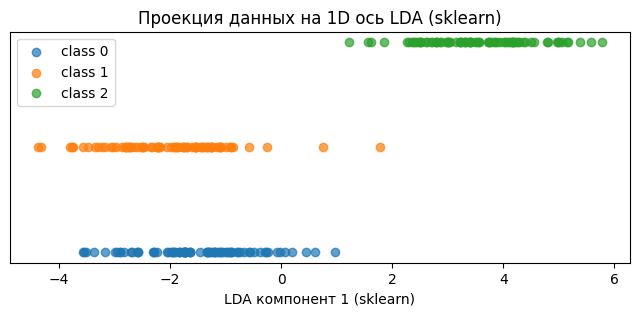

Точность классификации (LDA sklearn): 0.983


In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_sklearn = LinearDiscriminantAnalysis(n_components=1)
Z_sk = lda_sklearn.fit_transform(X, y)

plt.figure(figsize=(8, 3))
for cls, color in zip([0, 1, 2], ["tab:blue", "tab:orange", "tab:green"]):
    plt.scatter(Z_sk[y == cls, 0], np.zeros_like(Z_sk[y == cls, 0]) + cls * 0.1,
                color=color, alpha=0.7, label=f"class {cls}")
plt.yticks([])
plt.xlabel("LDA компонент 1 (sklearn)")
plt.title("Проекция данных на 1D ось LDA (sklearn)")
plt.legend()
plt.show()

y_pred_sk = lda_sklearn.predict(X)
acc_sk = (y_pred_sk == y).mean()
print(f"Точность классификации (LDA sklearn): {acc_sk:.3f}")


## Выводы

- LDA максимизирует отношение межклассового рассеяния к внутриклассовому (критерий Фишера) и даёт линейное отображение в пространство меньшей размерности; одна компонента часто уже хорошо разделяет классы.
- Реализация с нуля через матрицы S_W, S_B и обобщённую задачу собственных значений совпадает по смыслу с sklearn; проекции могут слегка отличаться из-за нормировок и выбора базиса.
- LDA удобен как интерпретируемое понижение размерности и быстрый линейный классификатор при приближённо гауссовых классах с общей ковариацией.